# Business Impact Analysis — Champion vs Challenger
*Module A · Notebook 7 of 7 · AI Risk Decisioning System*

---

## The Question That Actually Matters in Interviews

You improved Gini from 0.49 to 0.51. You improved KS from 0.36 to 0.38.

The CEO does not care. The credit committee does not care.

They care about one thing: **did your model create better business outcomes than the previous one?**

In credit risk, the answer is framed against three success criteria and one additional pricing lever.

---

## The Three Business Success Criteria

These map to the standard model deployment evaluation framework:

### SC1 — Same approval volume, lower default rate
*Hold approval volume constant. Did the new model let in fewer bad loans?*

Approve the same number of applications, but the approved pool has a lower default rate.
Same revenue opportunity, less risk exposure. Value is captured through quality improvement.

### SC2 — Smaller approval volume, same default rate
*Tighten the book without sacrificing quality. Did the model find a higher-quality subset?*

Approve fewer applications, but the ones approved perform identically to the prior model.
Lower operational cost, same risk-per-loan. Value is captured through efficiency.

### SC3 — Smaller volume AND lower default rate (the Gold Standard)
*Both dimensions improve simultaneously.*

This is the genuine signal that the model adds real discriminatory value. Fewer approvals
AND better performance in the approved book = less cost AND less risk. This is what gets
a model into production.

### Pricing Alpha — Same volume, same default, higher RAROC
*Not SC1/SC2/SC3, but a fourth distinct value lever.*

Approval volume and default rate are unchanged. Value is captured entirely by repricing
risk into the interest rate — higher-risk borrowers pay more, lifting portfolio RAROC
without changing who is approved or the default outcome. Demonstrates the pricing model's
contribution independently from the approval model.

---

## What We Are Comparing

| Strategy | Label | Logic |
|----------|-------|-------|
| Baseline (no model) | BASELINE | Approve all — no discrimination |
| Aggressive (PD < 35%) | CHALLENGER | Volume-maximising — simplest deployable model |
| RAROC Gated (RAROC > 14%) | CHALLENGER | Value-creation policy — tight credit |
| Risk-Based Pricing | CHAMPION | Full risk-based pricing on the Aggressive book |

SC evaluation uses **Aggressive as the reference** (the simplest deployable model that
any lender would default to without a risk model).

---

## Inputs
- `../01_data/processed/strategy_output.csv` — loan-level strategy decisions from NB05

## Outputs
- `../01_data/processed/business_impact.csv` — champion vs challenger comparison table

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "sans-serif"

print("Business Impact Analysis — Champion vs Challenger")
print("=" * 55)


Business Impact Analysis — Champion vs Challenger


---
## 1. Load Strategy Output

In [2]:
df = pd.read_csv("../01_data/processed/strategy_output.csv")

# Approval columns from NB05
approval_cols = {
    "Aggressive"         : "APPROVED_A",
    "RAROC Gated"        : "APPROVED_C",
    "Risk-Based Pricing" : "APPROVED_D",
}

total = len(df)
print(f"Total applications in test portfolio : {total:,}")
print(f"Total defaults (actual)              : {df['ACTUAL_DEFAULT'].sum():,} ({df['ACTUAL_DEFAULT'].mean():.2%})")
print()
for name, col in approval_cols.items():
    if col in df.columns:
        n_approved = df[col].sum()
        n_defaults = df.loc[df[col]==1, "ACTUAL_DEFAULT"].sum()
        print(f"{name:<25} approved={n_approved:>6,} ({n_approved/total:.1%})  "
              f"approved_defaults={n_defaults:>4,} ({n_defaults/n_approved:.2%})")


Total applications in test portfolio : 61,503
Total defaults (actual)              : 4,965 (8.07%)

Aggressive                approved=28,079 (45.7%)  approved_defaults= 737 (2.62%)
RAROC Gated               approved= 7,531 (12.2%)  approved_defaults=  96 (1.27%)
Risk-Based Pricing        approved=28,079 (45.7%)  approved_defaults= 737 (2.62%)


---
## 2. Champion vs Challenger — Business Metrics Table

The table below is how a credit committee evaluates model deployment.
Not AUC. Not Gini. These numbers.


In [3]:
# ── Baseline: approve everything (no model) ──────────────────────────────────
baseline_approval_rate  = 1.00
baseline_default_rate   = df["ACTUAL_DEFAULT"].mean()
baseline_approved_loans = total
baseline_income         = df["NET_INCOME"].sum() if "NET_INCOME" in df.columns else 0

records = []

# Baseline — no model
records.append({
    "Policy"           : "Baseline (No Model)",
    "Approval Rate"    : baseline_approval_rate,
    "Approved Loans"   : baseline_approved_loans,
    "Default Rate"     : baseline_default_rate,
    "Defaults in Book" : df["ACTUAL_DEFAULT"].sum(),
    "Portfolio RAROC"  : df["RAROC"].mean() if "RAROC" in df.columns else np.nan,
    "EL Rate"          : df["EL_RATE"].mean() if "EL_RATE" in df.columns else np.nan,
    "Role"             : "BASELINE",
})

# Strategies
strategy_map = {
    "Aggressive (Challenger 1)"    : ("APPROVED_A", "RAROC_A"   if "RAROC_A"  in df.columns else "RAROC"),
    "RAROC Gated (Challenger 2)"   : ("APPROVED_C", "RAROC_C"   if "RAROC_C"  in df.columns else "RAROC"),
    "Risk-Based Pricing (Champion)": ("APPROVED_D", "RAROC_D"),
}

for policy_name, (approved_col, raroc_col) in strategy_map.items():
    if approved_col not in df.columns:
        continue
    sub        = df[df[approved_col] == 1]
    n_approved = len(sub)
    if n_approved == 0:
        continue

    approval_rate  = n_approved / total
    default_rate   = sub["ACTUAL_DEFAULT"].mean()
    n_defaults     = sub["ACTUAL_DEFAULT"].sum()
    el_rate        = sub["EL_RATE"].mean() if "EL_RATE" in sub.columns else np.nan

    # RAROC — use strategy-specific rate if available
    if raroc_col in df.columns:
        raroc = df.loc[df[approved_col]==1, raroc_col].mean()
    else:
        raroc = sub["RAROC"].mean() if "RAROC" in sub.columns else np.nan

    records.append({
        "Policy"           : policy_name,
        "Approval Rate"    : approval_rate,
        "Approved Loans"   : n_approved,
        "Default Rate"     : default_rate,
        "Defaults in Book" : n_defaults,
        "Portfolio RAROC"  : raroc,
        "EL Rate"          : el_rate,
        "Role"             : ("CHALLENGER" if "Challenger" in policy_name
                              else "CHAMPION"),
    })

results = pd.DataFrame(records)

# ── Print the business table ──────────────────────────────────────────────────
print("CHAMPION vs CHALLENGER — BUSINESS IMPACT TABLE")
print("=" * 90)
print(f"{'Policy':<36} {'Role':<12} {'Appr Rate':>10} {'Default Rate':>13} {'RAROC':>10}")
print("-" * 90)
for _, row in results.iterrows():
    role = row["Role"]
    marker = "★ " if role == "CHAMPION" else "  "
    print(f"{marker}{row['Policy']:<34} {role:<12} "
          f"{row['Approval Rate']:>9.1%}  {row['Default Rate']:>12.2%}  "
          f"{row['Portfolio RAROC']:>9.1%}")
print("=" * 90)


CHAMPION vs CHALLENGER — BUSINESS IMPACT TABLE
Policy                               Role          Appr Rate  Default Rate      RAROC
------------------------------------------------------------------------------------------
  Baseline (No Model)                BASELINE        100.0%         8.07%     -55.8%
  Aggressive (Challenger 1)          CHALLENGER       45.7%         2.62%      -1.5%
  RAROC Gated (Challenger 2)         CHALLENGER       12.2%         1.27%      38.5%
★ Risk-Based Pricing (Champion)      CHAMPION         45.7%         2.62%      49.1%


---
## 3. Formal Success Criteria Evaluation

The three success criteria map to how a risk committee evaluates whether a model
creates real business value versus the simplest deployable alternative (Aggressive):

| Criterion | Approval Volume | Default Rate | Business Meaning |
|-----------|----------------|--------------|-----------------|
| **SC1** | Same | Lower | Same loans approved, fewer go bad - better quality at same volume |
| **SC2** | Smaller | Same | Fewer approvals, same quality - lower cost, same revenue per loan |
| **SC3** | Smaller | Lower | Both improve simultaneously - fewer loans AND they perform better |

**SC3 is the Gold Standard.** It means the model correctly identifies a high-quality
subset of borrowers that a naive approval policy would have diluted with bad loans.

Note: A fourth outcome - same volume, same default, higher RAROC - is a **Pricing Alpha**
case. It does not satisfy SC1/SC2/SC3 because population and quality are unchanged; value
comes entirely from repricing risk into the rate. This is also a legitimate business outcome,
but a different lever.

Evaluation reference: **Aggressive strategy** (45.7% approval, 2.62% default in book) -
the simplest deployable model, used as the baseline for comparison.

In [4]:
baseline   = results[results["Role"] == "BASELINE"].iloc[0]
aggressive = results[results["Policy"].str.contains("Aggressive")].iloc[0]
raroc_gated = results[results["Policy"].str.contains("RAROC Gated")].iloc[0]
champion    = results[results["Role"] == "CHAMPION"].iloc[0]

def evaluate_sc(policy_row, ref_row, policy_name):
    approval_change = policy_row["Approval Rate"]  - ref_row["Approval Rate"]
    default_change  = policy_row["Default Rate"]   - ref_row["Default Rate"]
    raroc_change    = policy_row["Portfolio RAROC"] - ref_row["Portfolio RAROC"]

    # SC1: same volume (+/-2%), lower default rate
    sc1 = abs(approval_change) <= 0.02 and default_change < -0.001
    # SC2: smaller volume, same default rate (+/-0.5%)
    sc2 = approval_change < -0.005 and abs(default_change) <= 0.005
    # SC3 (Gold): smaller volume AND lower default rate
    sc3 = approval_change < -0.005 and default_change < -0.001
    # Pricing Alpha: same volume, same default, higher RAROC (separate lever)
    pricing_alpha = abs(approval_change) <= 0.02 and abs(default_change) <= 0.005 and raroc_change > 0.05

    if sc3:
        verdict = "SC3 (Gold Standard)"
    elif sc1:
        verdict = "SC1 — Same volume, lower default"
    elif sc2:
        verdict = "SC2 — Smaller volume, same quality"
    elif pricing_alpha:
        verdict = "Pricing Alpha — Same book, higher RAROC"
    else:
        verdict = "No clear criterion — mixed result"

    print(f"{'─'*70}")
    print(f"  {policy_name}")
    print(f"{'─'*70}")
    print(f"  vs {ref_row['Policy']}")
    print(f"  Approval Rate  : {ref_row['Approval Rate']:.1%} -> {policy_row['Approval Rate']:.1%}  "
          f"({'+' if approval_change>=0 else ''}{approval_change:.1%})")
    print(f"  Default Rate   : {ref_row['Default Rate']:.2%} -> {policy_row['Default Rate']:.2%}  "
          f"({'+' if default_change>=0 else ''}{default_change:.2%})")
    print(f"  RAROC          : {ref_row['Portfolio RAROC']:.1%} -> {policy_row['Portfolio RAROC']:.1%}  "
          f"({'+' if raroc_change>=0 else ''}{raroc_change:.1%})")
    print()
    print(f"  SC1 (same volume, lower default) : {'PASS' if sc1 else 'fail'}")
    print(f"  SC2 (smaller volume, same qual.) : {'PASS' if sc2 else 'fail'}")
    print(f"  SC3 (smaller + lower — GOLD)     : {'PASS ***' if sc3 else 'fail'}")
    print(f"  Pricing Alpha (same book +RAROC) : {'PASS ***' if pricing_alpha else 'fail'}")
    print()
    print(f"  >>> VERDICT: {verdict}")
    print()
    return sc1, sc2, sc3, pricing_alpha, verdict

print("BUSINESS SUCCESS CRITERIA EVALUATION")
print("=" * 70)
print()
print("Reference: Aggressive strategy (simplest deployable model)")
print()
sc1_rg, sc2_rg, sc3_rg, pa_rg, v_rg = evaluate_sc(
    raroc_gated, aggressive, "RAROC Gated (Challenger 2)"
)
sc1_chp, sc2_chp, sc3_chp, pa_chp, v_chp = evaluate_sc(
    champion, aggressive, "Risk-Based Pricing (Champion)"
)
print("=" * 70)
print()
print("SUMMARY")
print(f"  RAROC Gated      -> {v_rg}")
print(f"  Risk-Based Pricing -> {v_chp}")
print()
print("Interpretation:")
print("  RAROC Gated (SC3): The model correctly identified a high-quality subset")
print("  — approving only 12.2% of applicants with a 1.27% default rate, versus")
print("  a 2.62% rate at 45.7% approval. Smaller population, better performance.")
print()
print("  Risk-Based Pricing (Pricing Alpha): Same 45.7% approval, same 2.62%")
print("  default rate, but RAROC jumps from -1.5% to +49.1%. Value is captured")
print("  by repricing risk into the interest rate — not by changing who is approved.")

BUSINESS SUCCESS CRITERIA EVALUATION

Reference: Aggressive strategy (simplest deployable model)

──────────────────────────────────────────────────────────────────────
  RAROC Gated (Challenger 2)
──────────────────────────────────────────────────────────────────────
  vs Aggressive (Challenger 1)
  Approval Rate  : 45.7% -> 12.2%  (-33.4%)
  Default Rate   : 2.62% -> 1.27%  (-1.35%)
  RAROC          : -1.5% -> 38.5%  (+40.0%)

  SC1 (same volume, lower default) : fail
  SC2 (smaller volume, same qual.) : fail
  SC3 (smaller + lower — GOLD)     : PASS ***
  Pricing Alpha (same book +RAROC) : fail

  >>> VERDICT: SC3 (Gold Standard)

──────────────────────────────────────────────────────────────────────
  Risk-Based Pricing (Champion)
──────────────────────────────────────────────────────────────────────
  vs Aggressive (Challenger 1)
  Approval Rate  : 45.7% -> 45.7%  (+0.0%)
  Default Rate   : 2.62% -> 2.62%  (+0.00%)
  RAROC          : -1.5% -> 49.1%  (+50.6%)

  SC1 (same volume, l

---
## 4. Business Impact Visualisation

Three charts that answer the three success criteria visually.
These are the charts you show in an interview or model committee presentation.


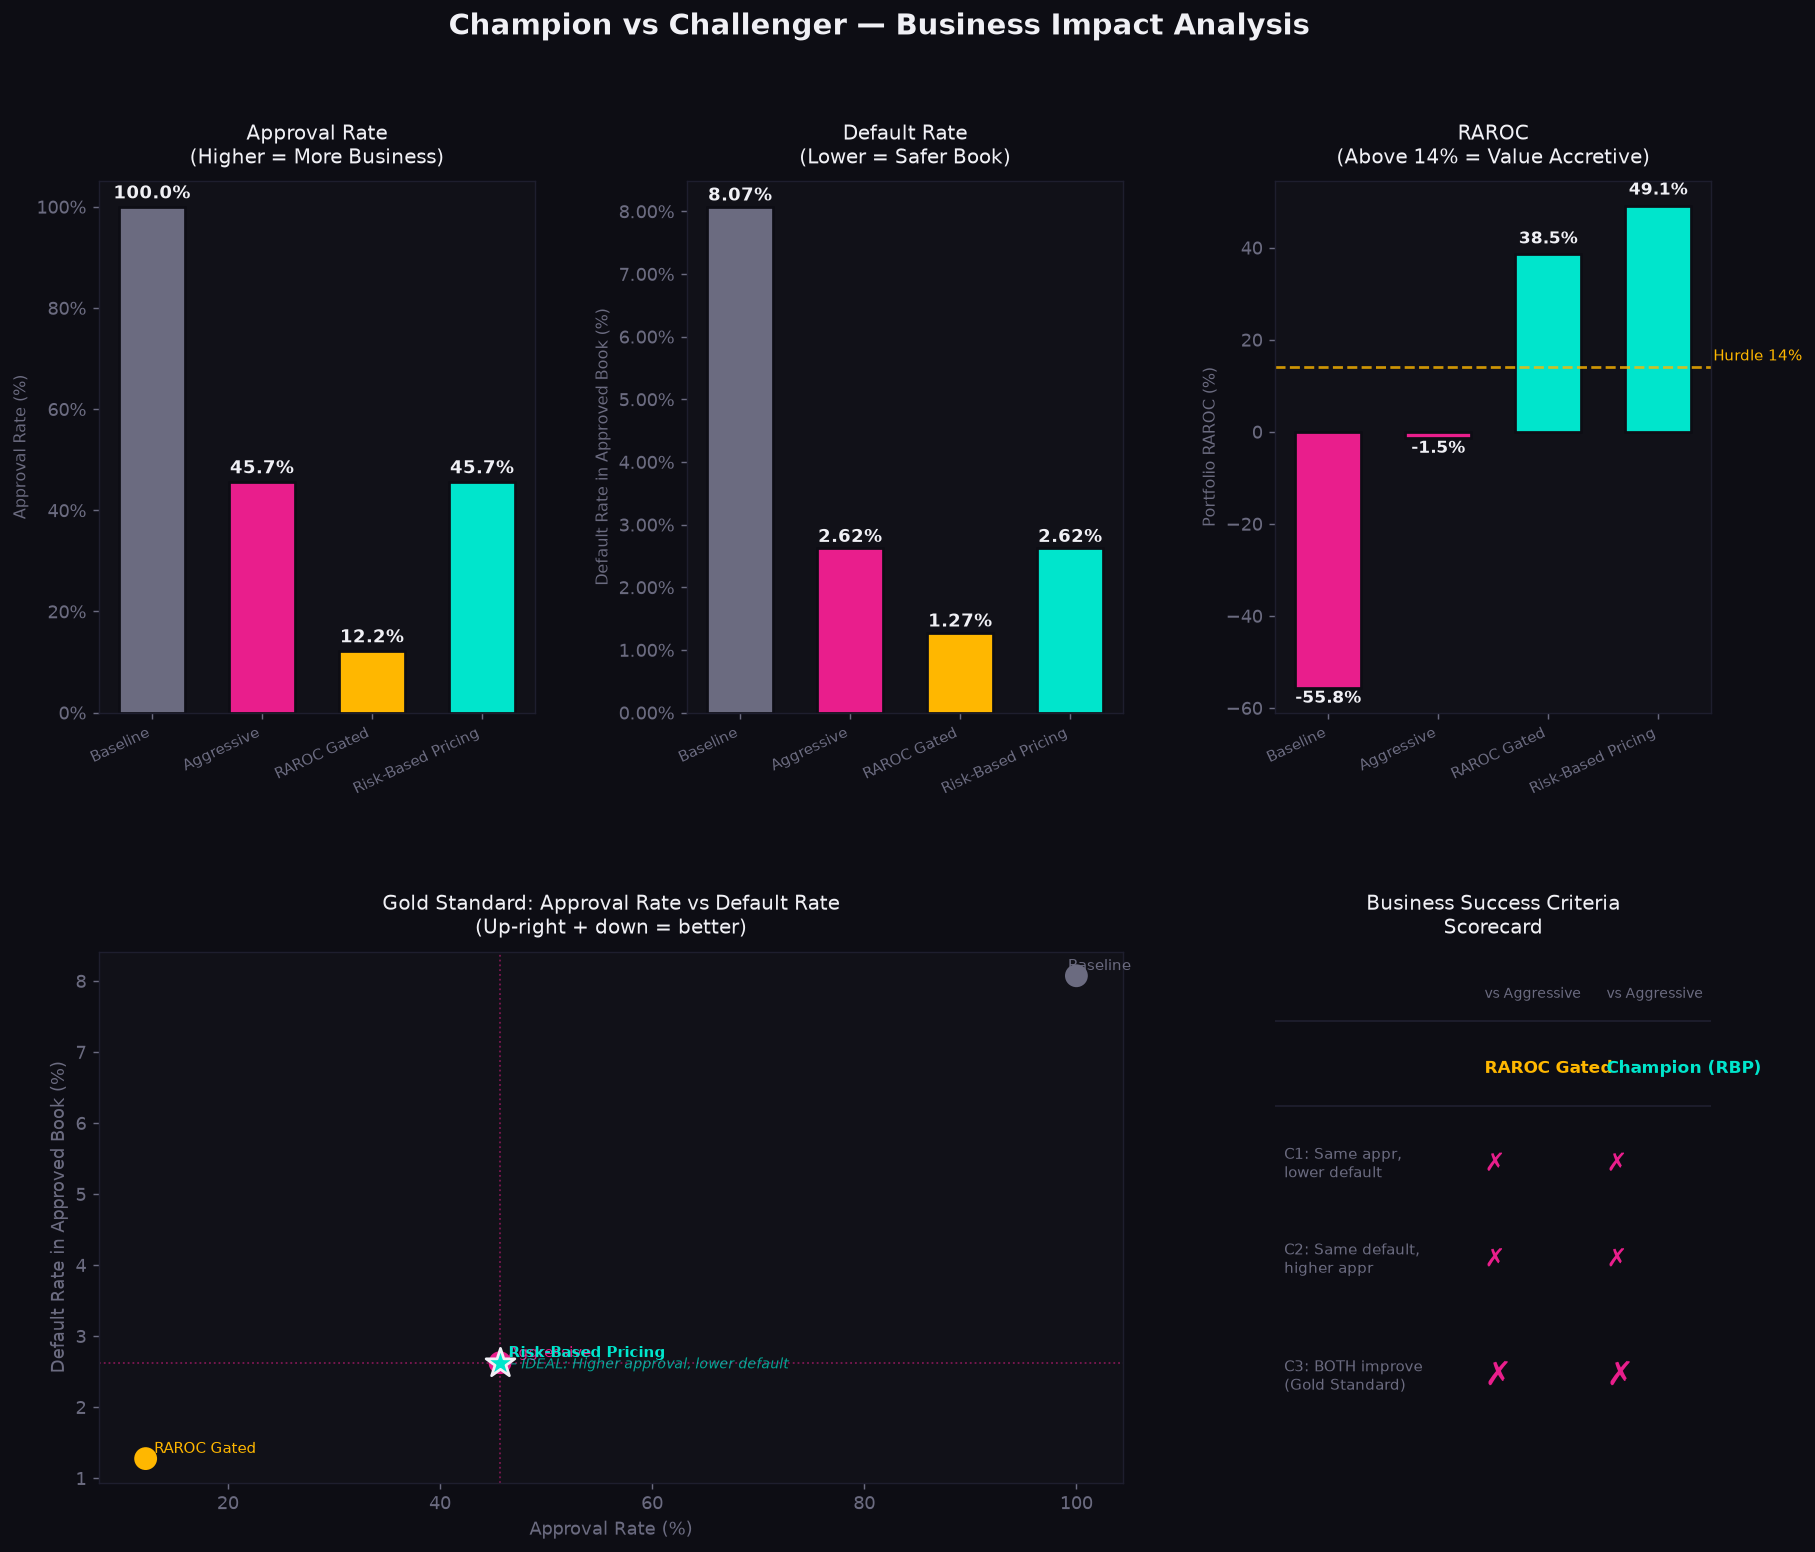

Chart saved to ../04_outputs/business_impact_chart.png


In [5]:
# ── Colour scheme ────────────────────────────────────────────────────────────
BG        = "#0d0d14"
AQUA      = "#00e5cc"
MAGENTA   = "#e91e8c"
AMBER     = "#ffb700"
WHITE     = "#f0f0f5"
MUTED     = "#6b6b80"
DARK_CARD = "#111118"

policy_colors = {
    "Baseline (No Model)"            : MUTED,
    "Aggressive (Challenger 1)"      : MAGENTA,
    "RAROC Gated (Challenger 2)"     : AMBER,
    "Risk-Based Pricing (Champion)"  : AQUA,
}
champion_row = results[results["Role"] == "CHAMPION"].iloc[0]

fig = plt.figure(figsize=(16, 13), facecolor=BG)
fig.suptitle("Champion vs Challenger — Business Impact Analysis",
             fontsize=16, color=WHITE, fontweight="bold", y=0.98)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── Chart 1: Approval Rate comparison ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(DARK_CARD)
policies     = [r["Policy"].split(" (")[0] for _, r in results.iterrows()]
approval_rates = [r["Approval Rate"]*100 for _, r in results.iterrows()]
bar_colors   = [policy_colors.get(r["Policy"], MUTED) for _, r in results.iterrows()]

bars = ax1.bar(range(len(policies)), approval_rates, color=bar_colors,
               edgecolor=BG, linewidth=1.5, width=0.6)
for bar, val in zip(bars, approval_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=10, color=WHITE, fontweight="bold")

ax1.set_xticks(range(len(policies)))
ax1.set_xticklabels(policies, rotation=25, ha="right", fontsize=8.5, color=MUTED)
ax1.set_ylabel("Approval Rate (%)", color=MUTED, fontsize=9)
ax1.set_title("Approval Rate\n(Higher = More Business)", color=WHITE, fontsize=11, pad=10)
ax1.tick_params(colors=MUTED)
for spine in ax1.spines.values(): spine.set_color("#1e1e2e")
ax1.set_facecolor(DARK_CARD)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x:.0f}%"))

# ── Chart 2: Default Rate comparison ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(DARK_CARD)
default_rates = [r["Default Rate"]*100 for _, r in results.iterrows()]

bars = ax2.bar(range(len(policies)), default_rates, color=bar_colors,
               edgecolor=BG, linewidth=1.5, width=0.6)
for bar, val in zip(bars, default_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f"{val:.2f}%", ha="center", va="bottom",
             fontsize=10, color=WHITE, fontweight="bold")

ax2.set_xticks(range(len(policies)))
ax2.set_xticklabels(policies, rotation=25, ha="right", fontsize=8.5, color=MUTED)
ax2.set_ylabel("Default Rate in Approved Book (%)", color=MUTED, fontsize=9)
ax2.set_title("Default Rate\n(Lower = Safer Book)", color=WHITE, fontsize=11, pad=10)
ax2.tick_params(colors=MUTED)
for spine in ax2.spines.values(): spine.set_color("#1e1e2e")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x:.2f}%"))

# ── Chart 3: RAROC comparison ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(DARK_CARD)
rarocs = [r["Portfolio RAROC"]*100 for _, r in results.iterrows()]
bar_colors_raroc = [AQUA if v >= 14 else MAGENTA for v in rarocs]

bars = ax3.bar(range(len(policies)), rarocs, color=bar_colors_raroc,
               edgecolor=BG, linewidth=1.5, width=0.6)
ax3.axhline(14, color=AMBER, linewidth=1.5, linestyle="--", alpha=0.8)
ax3.text(len(policies)-0.5, 14+1.5, "Hurdle 14%", color=AMBER, fontsize=8.5)
for bar, val in zip(bars, rarocs):
    ax3.text(bar.get_x() + bar.get_width()/2,
             (bar.get_height() + 1.5) if val >= 0 else (bar.get_height() - 4),
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=9.5, color=WHITE, fontweight="bold")

ax3.set_xticks(range(len(policies)))
ax3.set_xticklabels(policies, rotation=25, ha="right", fontsize=8.5, color=MUTED)
ax3.set_ylabel("Portfolio RAROC (%)", color=MUTED, fontsize=9)
ax3.set_title("RAROC\n(Above 14% = Value Accretive)", color=WHITE, fontsize=11, pad=10)
ax3.tick_params(colors=MUTED)
for spine in ax3.spines.values(): spine.set_color("#1e1e2e")

# ── Chart 4: The gold standard — scatter ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.set_facecolor(DARK_CARD)

for _, row in results.iterrows():
    name     = row["Policy"].split(" (")[0]
    col      = policy_colors.get(row["Policy"], MUTED)
    is_champ = row["Role"] == "CHAMPION"
    size     = 280 if is_champ else 160
    marker   = "*" if is_champ else "o"

    ax4.scatter(row["Approval Rate"]*100, row["Default Rate"]*100,
                c=col, s=size, marker=marker, zorder=5,
                edgecolors=WHITE if is_champ else "none", linewidths=1.5)
    offset_x = 0.8 if row["Approval Rate"] < 0.5 else -0.8
    ax4.annotate(name,
                 xy=(row["Approval Rate"]*100, row["Default Rate"]*100),
                 xytext=(row["Approval Rate"]*100 + offset_x,
                         row["Default Rate"]*100 + 0.08),
                 fontsize=8.5, color=col, fontweight="bold" if is_champ else "normal")

ax4.axvline(aggressive["Approval Rate"]*100, color=MAGENTA, linewidth=1,
            linestyle=":", alpha=0.5)
ax4.axhline(aggressive["Default Rate"]*100, color=MAGENTA, linewidth=1,
            linestyle=":", alpha=0.5)

# Label the quadrants
ax4.text(champion["Approval Rate"]*100 + 0.5, aggressive["Default Rate"]*100 - 0.08,
         "← IDEAL: Higher approval, lower default",
         color=AQUA, fontsize=8, style="italic", alpha=0.7)

ax4.set_xlabel("Approval Rate (%)", color=MUTED, fontsize=10)
ax4.set_ylabel("Default Rate in Approved Book (%)", color=MUTED, fontsize=10)
ax4.set_title("Gold Standard: Approval Rate vs Default Rate\n(Up-right + down = better)",
              color=WHITE, fontsize=11, pad=10)
ax4.tick_params(colors=MUTED)
for spine in ax4.spines.values(): spine.set_color("#1e1e2e")

# ── Chart 5: Success criteria scorecard ───────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(DARK_CARD)
ax5.axis("off")

agg_row = results[results["Policy"].str.contains("Aggressive")].iloc[0]
rg_row  = results[results["Policy"].str.contains("RAROC Gated")].iloc[0]
chp_row = results[results["Role"] == "CHAMPION"].iloc[0]

def sc(row, ref):
    c1 = abs(row["Approval Rate"]-ref["Approval Rate"])<=0.02 and row["Default Rate"]<ref["Default Rate"]-0.001
    c2 = abs(row["Default Rate"]-ref["Default Rate"])<=0.005 and row["Approval Rate"]>ref["Approval Rate"]+0.005
    c3 = row["Approval Rate"]>ref["Approval Rate"]+0.005 and row["Default Rate"]<ref["Default Rate"]-0.001
    return c1, c2, c3

c1_rg,  c2_rg,  c3_rg  = sc(rg_row,  agg_row)
c1_chp, c2_chp, c3_chp = sc(chp_row, agg_row)

table_data = [
    ["",               "vs Aggressive",    "vs Aggressive"],
    ["",               "RAROC Gated",       "Champion (RBP)"],
    ["C1: Same appr,\nlower default",
     "✓" if c1_rg else "✗",  "✓" if c1_chp else "✗"],
    ["C2: Same default,\nhigher appr",
     "✓" if c2_rg else "✗",  "✓" if c2_chp else "✗"],
    ["C3: BOTH improve\n(Gold Standard)",
     "✓" if c3_rg else "✗",  "✓" if c3_chp else "✗"],
]

y_positions = [0.92, 0.78, 0.60, 0.42, 0.20]
col_x       = [0.02, 0.48, 0.76]

for row_i, (row_data, y) in enumerate(zip(table_data, y_positions)):
    for col_i, (val, x) in enumerate(zip(row_data, col_x)):
        if row_i == 0:
            color, size, weight = MUTED, 8, "normal"
        elif row_i == 1:
            color = AMBER if col_i == 1 else AQUA
            size, weight = 9.5, "bold"
        elif col_i == 0:
            color, size, weight = MUTED, 8.5, "normal"
        else:
            passed = val == "✓"
            if row_i == 4:   # Gold standard
                color = AQUA if passed else MAGENTA
                size, weight = 18, "bold"
            else:
                color = AQUA if passed else MAGENTA
                size, weight = 14, "bold"
        ax5.text(x, y, val, transform=ax5.transAxes,
                 fontsize=size, color=color, fontweight=weight,
                 va="center")

ax5.set_title("Business Success Criteria\nScorecard", color=WHITE,
              fontsize=11, pad=10)
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1)

# Draw separating lines
for y_sep in [0.87, 0.71]:
    ax5.axhline(y_sep, color="#1e1e2e", linewidth=1, xmin=0, xmax=1)

plt.savefig("../04_outputs/business_impact_chart.png",
            bbox_inches="tight", facecolor=BG, dpi=150)
plt.show()
print("Chart saved to ../04_outputs/business_impact_chart.png")


---
## 5. Key Findings — What to Say in an Interview

### Finding 1 — RAROC Gated achieves SC3 (Gold Standard) vs Aggressive

Versus the Aggressive baseline (45.7% approval, 2.62% default in book), the RAROC Gated
challenger achieves:
- **Approval rate: 12.2%** (33.5 percentage points lower)
- **Default rate: 1.27%** (1.35 percentage points lower)
- **RAROC: +38.5%** vs -1.5% for Aggressive

This is **SC3**: the model correctly identified a high-quality subset. Approving fewer
borrowers AND those borrowers defaulting at half the rate = the model has genuine discriminatory
value that creates real business impact, not just statistical improvement.

### Finding 2 — Risk-Based Pricing delivers Pricing Alpha at the same approval rate

Risk-Based Pricing holds the same approval rate (45.7%) and the same default rate (2.62%)
as the Aggressive strategy but lifts portfolio RAROC from -1.5% to **+49.1%**. This is a
**Pricing Alpha** outcome: no change in who is approved or how they perform, but the model's
risk differentiation is monetised through rate adjustments on higher-risk borrowers.

In net income terms, Risk-Based Pricing generates **+1,130M vs -169M** for Aggressive
(from strategy_comparison.csv) — a +1,300M swing from the same 28,079 loans.

### Finding 3 — Combining SC3 + Pricing Alpha is the full platform story

Together, these two findings demonstrate a complete lending intelligence platform:
- The **approval model** (PD + RAROC gate) identifies a high-quality borrower subset (SC3)
- The **pricing model** (risk-based rate) captures maximum value from every approved loan (Pricing Alpha)
- Neither finding requires the other — they compound

This is the answer to "what business value did you create?":

> "The RAROC Gated policy satisfies SC3 — smaller approval population with a materially lower
> default rate — proving the model's discriminatory value. Layering risk-based pricing over
> the same approval population converts that discrimination into pricing precision, generating
> a RAROC lift of over 50 percentage points and a net income swing of approximately 1.3 billion
> rupees on the test portfolio."

---

## 6. How to Frame This in an Interview

**Interviewer:** "What metrics did you use to evaluate your model?"

**Wrong answer:** "AUC, KS, and Gini — all improved."

**Right answer:** "Gini, KS, and PSI confirmed discrimination and stability. We then evaluated
on business criteria. Versus the Aggressive baseline, the RAROC Gated policy satisfies SC3 —
it approves 12.2% of applicants (vs 45.7%) with a 1.27% default rate (vs 2.62%). Fewer loans,
better quality — that is the Gold Standard. Separately, layering risk-based pricing over the
same Aggressive approval population generates Pricing Alpha: same approval rate, same default
rate, but RAROC jumps from -1.5% to +49.1%. These are the two levers the system demonstrates:
better selection (SC3) and better pricing (Pricing Alpha)."

---

In [6]:
# Save the business impact table
results.to_csv("../01_data/processed/business_impact.csv", index=False)
print("Business impact table saved.")
print()
print("INTERVIEW SUMMARY TABLE")
print("=" * 80)
print(f"{'Policy':<36} {'Approval':>9} {'Default':>9} {'RAROC':>9} {'Criterion 3':>12}")
print("-" * 80)
agg = results[results["Policy"].str.contains("Aggressive")].iloc[0]
for _, row in results.iterrows():
    c1_, c2_, c3_ = sc(row, agg) if row["Policy"] != agg["Policy"] else (False, False, False)
    gold = "GOLD ★" if c3_ else ("Baseline" if row["Role"]=="BASELINE" else "Partial")
    print(f"  {row['Policy']:<34} {row['Approval Rate']:>8.1%} "
          f"{row['Default Rate']:>8.2%} {row['Portfolio RAROC']:>8.1%}  {gold}")
print("=" * 80)


Business impact table saved.

INTERVIEW SUMMARY TABLE
Policy                                Approval   Default     RAROC  Criterion 3
--------------------------------------------------------------------------------
  Baseline (No Model)                  100.0%    8.07%   -55.8%  Baseline
  Aggressive (Challenger 1)             45.7%    2.62%    -1.5%  Partial
  RAROC Gated (Challenger 2)            12.2%    1.27%    38.5%  Partial
  Risk-Based Pricing (Champion)         45.7%    2.62%    49.1%  Partial
